In [27]:
import pandas as pd

test_df = pd.read_csv("data/train_01.csv")
display(test_df.head(10))

,property_id,description,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,price_tier
0,18686390,Cozy Studio in the Heart of the East Village,Manhattan,East Village,40.72415,-73.98411,Entire home/apt,1,13,1,0,2
1,27703757,Beautiful 4 Bdrm Home - 25 min from Manhattan,Queens,Laurelton,40.67525,-73.74625,Entire home/apt,2,6,2,321,2
2,27552471,Best Brighton Beach welcoming for your stay!,Brooklyn,Brighton Beach,40.57762,-73.96051,Entire home/apt,2,2,1,0,1
3,16917171,West Village - 1 Bedroom,Manhattan,West Village,40.73459,-74.00143,Entire home/apt,2,1,1,0,2
4,32984848,2 Bedroom Clean & Simple in Manhattan,Manhattan,Chinatown,40.71358,-73.99062,Entire home/apt,3,7,1,49,2
5,6220514,Amazing 3 bedrooms in East Village,Manhattan,East Village,40.72551,-73.97893,Entire home/apt,30,25,1,0,2
6,34275461,BedStuy Penthouse Duplex 1BR,Brooklyn,Bedford-Stuyvesant,40.68417,-73.95343,Entire home/apt,30,1,1,191,2
7,13576581,Modern Central Park Apartment close to everything,Manhattan,Harlem,40.80573,-73.94994,Entire home/apt,1,160,3,246,2
8,30344630,Upper East Side 1 Bedroom,Manhattan,Upper East Side,40.77538,-73.94857,Entire home/apt,30,0,1,158,2
9,32884505,"Cozy, spacious room in Bed-Stuy",Brooklyn,Bedford-Stuyvesant,40.68845,-73.94390,Private room,1,7,1,0,0


In [7]:

train_df = pd.read_csv("data/train_01.csv")
print(train_df["description"].nunique())

1798


In [33]:
(train_df.isna() | train_df.eq("")).sum()

property_id                       0
description                       0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
price_tier                        0
dtype: int64

In [ ]:
# Description 

from collections import Counter
import pandas as pd

rows = []

for tier in sorted(train_df["price_tier"].unique()):
    text = " ".join(
        train_df.loc[train_df["price_tier"] == tier, "description"]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    for word, count in Counter(text.split()).most_common(25):
        rows.append([tier, word, count])

df_words = pd.DataFrame(
    rows,
    columns=["price_tier", "Word", "Count"]
)

display(df_words)

,price_tier,Word,Count
0,0,room,191
1,0,in,182
2,0,private,114
3,0,bedroom,62
4,0,cozy,54
5,0,to,44
6,0,brooklyn,43
7,0,a,37
8,0,manhattan,32
9,0,&,32


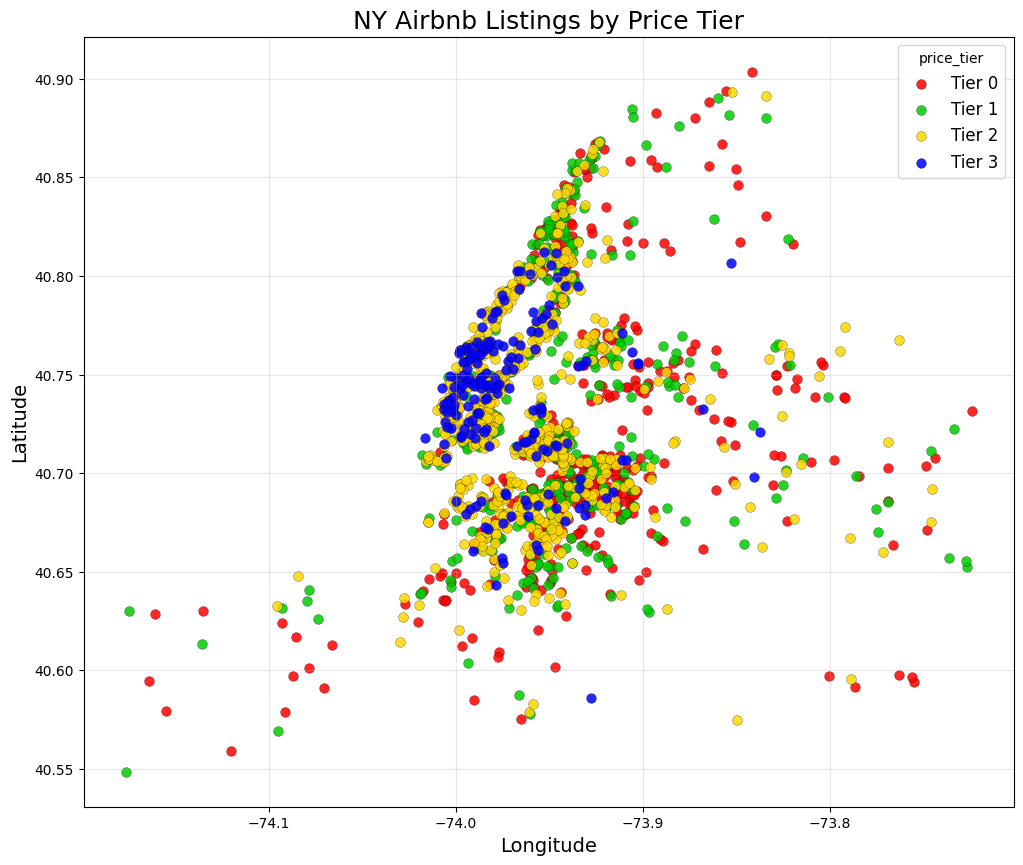

In [ ]:
# Longitude and altitude 

import pandas as pd
import matplotlib.pyplot as plt

test_df = pd.read_csv("data/train_01.csv")

colors = {
    0: "#ff0000",  # red
    1: "#00cc00",  # green
    2: "#ffd700",  # gold
    3: "#0000ff"   # blue
}

plt.figure(figsize=(12, 10))

for tier, color in colors.items():
    subset = test_df[test_df["price_tier"] == tier]

    plt.scatter(
        subset["longitude"],
        subset["latitude"],
        c=color,
        label=f"Tier {tier}",
        alpha=0.85,
        s=50,
        edgecolors="black",
        linewidths=0.2
    )

plt.xlabel("Longitude", fontsize=14)
plt.ylabel("Latitude", fontsize=14)
plt.title("NY Airbnb Listings by Price Tier", fontsize=18)
plt.legend(title="price_tier", fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()